Jamboree has helped thousands of students like you make it to top colleges abroad. Be it GMAT, GRE or SAT, their unique problem-solving methods ensure maximum scores with minimum effort.
They recently launched a feature where students/learners can come to their website and check their probability of getting into the IVY league college. This feature estimates the chances of graduate admission from an Indian perspective.

__Problem Statement:__ Analyse the predictor variables to draw insights about the importance of various factors in prediction of chances of graduate admission and how they are related to each other.

_Column Profiling:_  
• Serial No. (Unique row ID)  
• GRE Scores (out of 340)  
• TOEFL Scores (out of 120)  
• University Rating (out of 5)  
• Statement of Purpose and Letter of Recommendation Strength (out of 5)  
• Undergraduate GPA (out of 10)  
• Research Experience (either 0 or 1)  
• Chance of Admit (ranging from 0 to 1)

### Importing the data

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
df = pd.read_csv("Jamboree_Admission.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [108]:
df.shape

(500, 9)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


There are 500 rows and 9 columns

In [110]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


In [111]:
# unique values in the dataset
for col in df:
    print(f'Number of unique values in the {col} column:',df[col].nunique(),'  ')

Number of unique values in the Serial No. column: 500   
Number of unique values in the GRE Score column: 49   
Number of unique values in the TOEFL Score column: 29   
Number of unique values in the University Rating column: 5   
Number of unique values in the SOP column: 9   
Number of unique values in the LOR  column: 9   
Number of unique values in the CGPA column: 184   
Number of unique values in the Research column: 2   
Number of unique values in the Chance of Admit  column: 61   


Checking duplicates and missing values

In [112]:
df.duplicated().sum()

0

In [113]:
df.isna().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

There are no duplicates and no missing values in the data

_Observations:_

- There are 500 rows and 9 columns
- No Missing value observed in any feature
- It is observed that the maximum value in each column is not big enough so we can reduce the size of the data type which will help our data consume less memory
- All the columns are of data type int or float
- Unique values in some columns are below 10, which can be converted to categorical columns

## Exploratory Data Analysis

In [114]:
#Remove the column serial no as it is not useful in the Analysis
df.drop(columns=['Serial No.'], inplace=True)

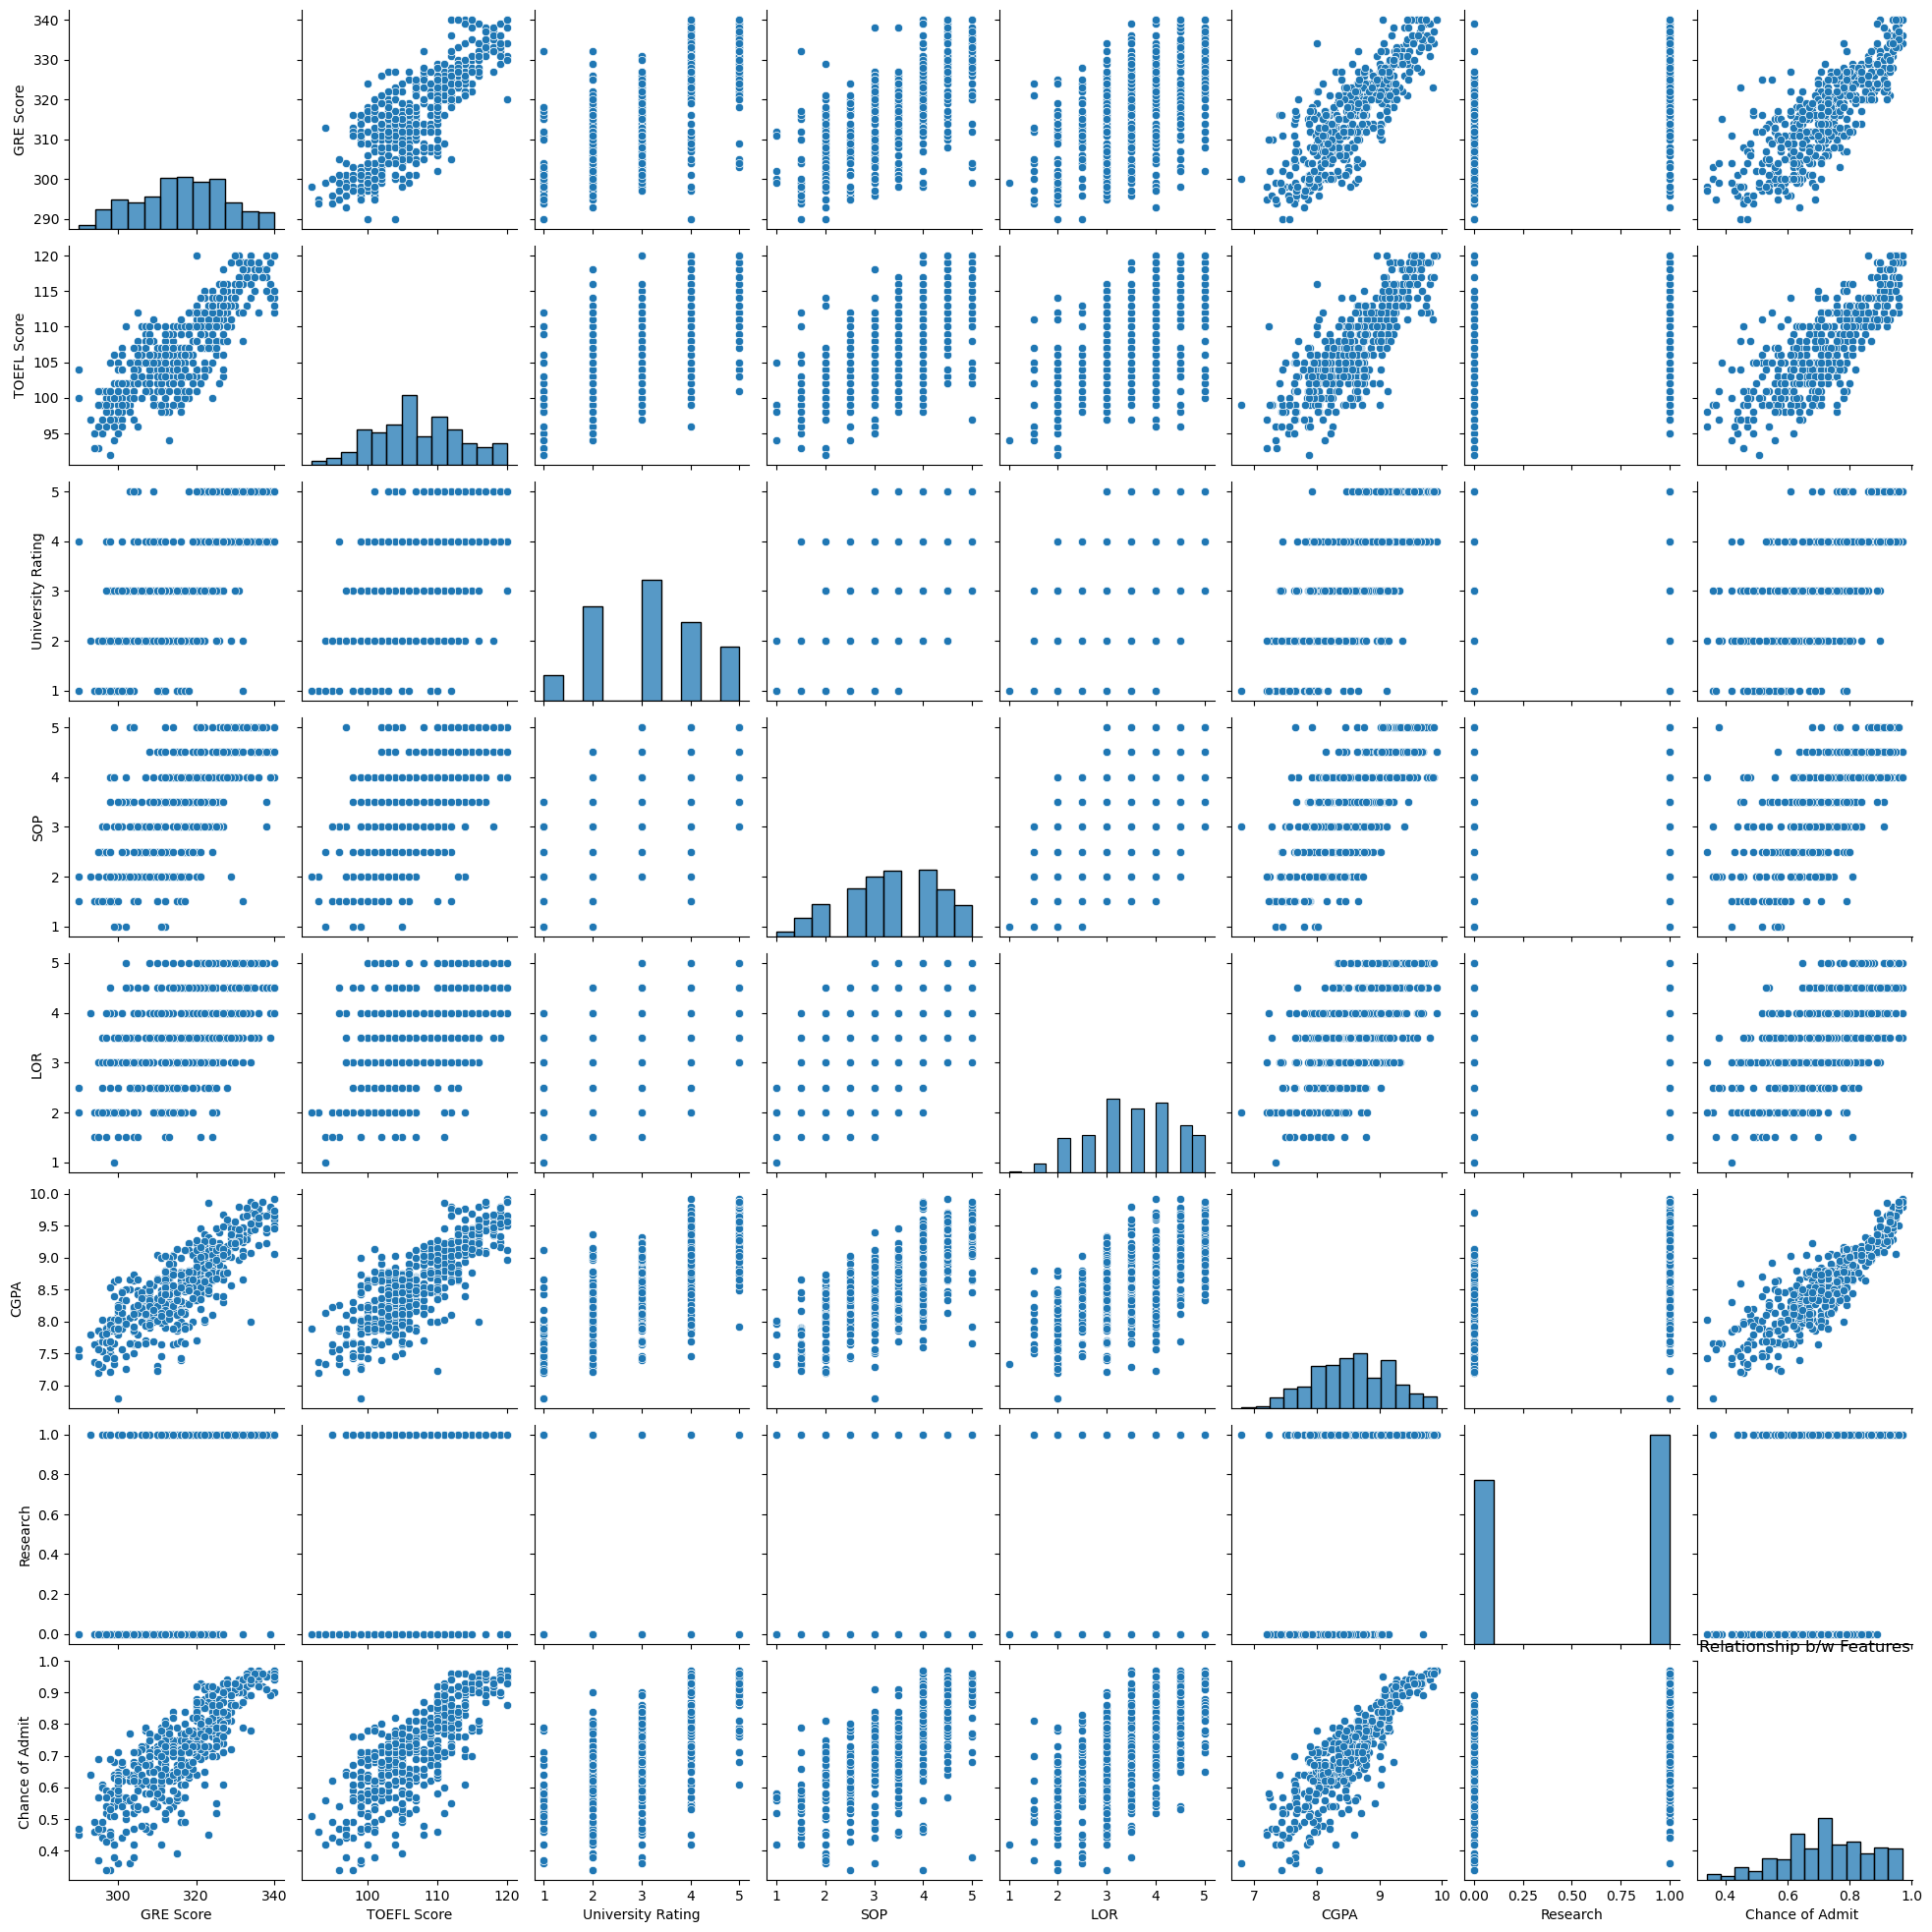

In [115]:
sns.pairplot(df)
plt.title('Relationship b/w Features')
plt.show();

- Exam scores (GRE, TOEFL and CGPA) have a high positive correlation with chance of admit  
- University ranking, rating of SOP and LOR also have an impact on chances of admit
- We can see from the scatterplot that the values of university ranking, SOP, LOR and research are not continuous. We can convert these columns to categorical variables

In [116]:
# Remove extra spaces in column headers
df.rename(columns={'LOR ':'LOR', 'Chance of Admit ':'Chance of Admit'} , inplace=True)

In [117]:
df[['University Rating','SOP','LOR' ]]=df[['University Rating','SOP','LOR' ]].astype('category')
df[['Research']] = df[['Research']].astype('bool')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   GRE Score          500 non-null    int64   
 1   TOEFL Score        500 non-null    int64   
 2   University Rating  500 non-null    category
 3   SOP                500 non-null    category
 4   LOR                500 non-null    category
 5   CGPA               500 non-null    float64 
 6   Research           500 non-null    bool    
 7   Chance of Admit    500 non-null    float64 
dtypes: bool(1), category(3), float64(2), int64(2)
memory usage: 18.6 KB


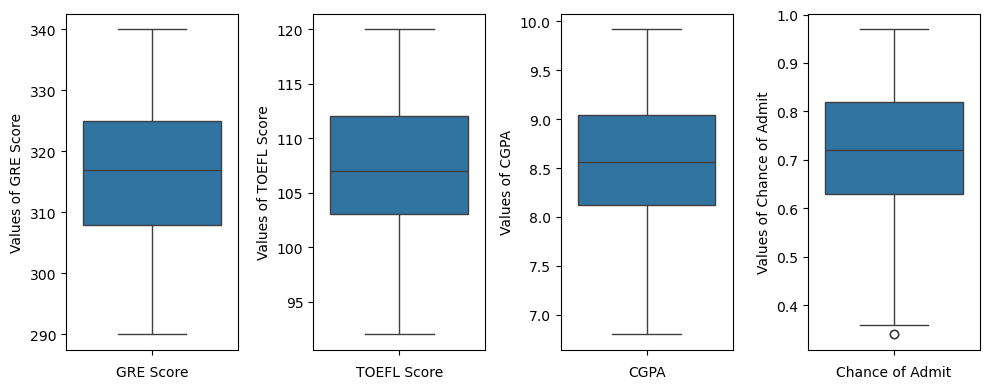

In [118]:
# Check for outliers in numerical columns
num_col = ['GRE Score','TOEFL Score', 'CGPA', 'Chance of Admit']
plt.figure(figsize=(10,4))
i=1
for col in num_col:
  ax = plt.subplot(1,4,i)
  sns.boxplot(df[col])
  #plt.title(col)
  plt.xlabel(col)
  plt.ylabel(f'Values of {col}')
  i+=1
plt.tight_layout()
plt.show()

There are no outliers in the data, except one in the 'chance of admit' which is negligible

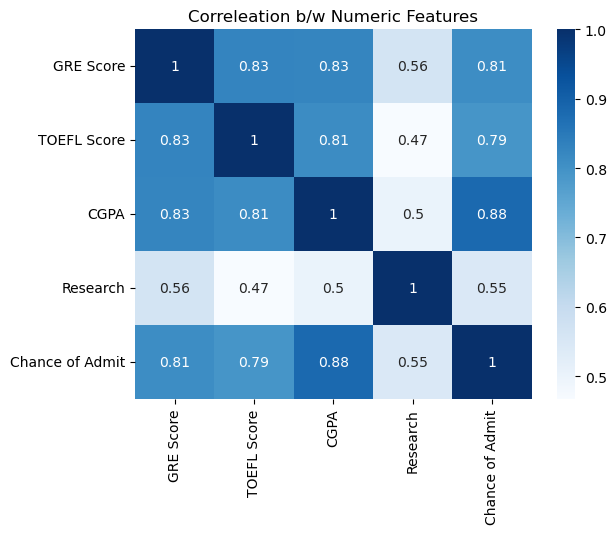

In [154]:
#Heatmap to analyse the correlation between numerical features and Chance of Admit
df_corr = df.corr(numeric_only=True)
sns.heatmap(df_corr,annot=True,cmap='Blues')
plt.title("Correleation b/w Numeric Features")
plt.show()

__Observations :__
- Confirming the inferences from pairplot, the correlation matrix also shows that exam scores (CGPA/GRE/TOEFL) have a strong positive correlation with chance of admit
- Infact, they are also highly correlated amongst themselves

## Distribution of Variables

-  Univariate analysis
-  Bivariate analysis

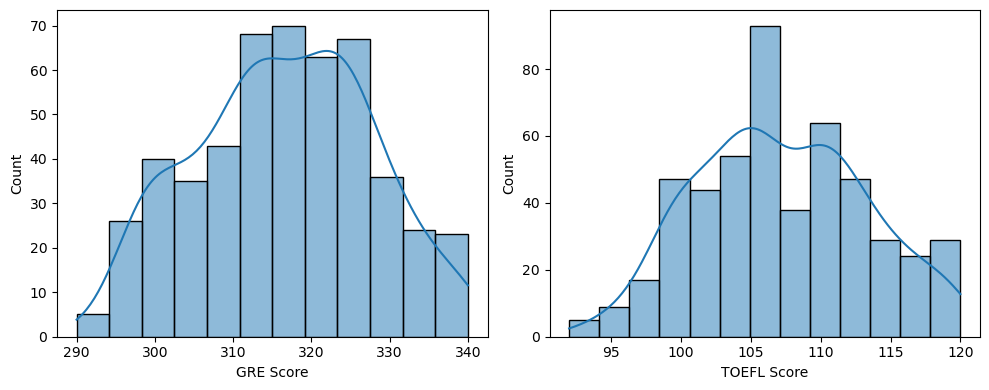

In [155]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df['GRE Score'],ax=axs[0],kde=True)

sns.histplot(df['TOEFL Score'],ax=axs[1],kde=True)

plt.tight_layout()
plt.show()

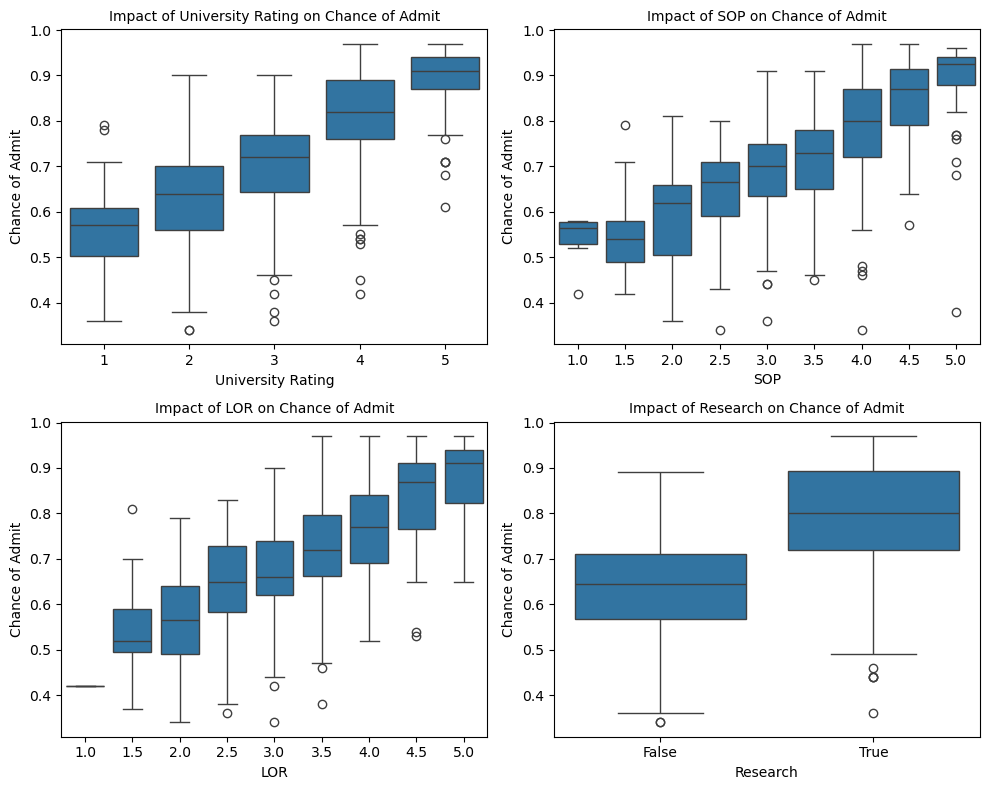

In [121]:
# Boxplots to analyse the relationship between categorical variables and Chance of Admit

cat_cols = df.select_dtypes(include=['bool','category']).columns.tolist()
plt.figure(figsize=(10,8))
i=1
for col in cat_cols:
  ax = plt.subplot(2,2,i)
  sns.boxplot(data = df, x=col, y='Chance of Admit')
  plt.title(f"Impact of {col} on Chance of Admit", fontsize=10)
  plt.xlabel(col)
  plt.ylabel('Chance of Admit')
  i+=1

plt.tight_layout()
plt.show()

INSIGHTS:
- Chance of Admit is highest for University with rating 5 followed by 4,3,2,1
- Chance of admit is maximum for SOP strength of 5 and henceforth decreasing uptil 1
- LOR with strength 5 has the maximum chance of admit
- Students who have done research have higher chance of admit

## Building Linear regression

In [122]:
df.head(5)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,True,0.92
1,324,107,4,4.0,4.5,8.87,True,0.76
2,316,104,3,3.0,3.5,8.00,True,0.72
3,322,110,3,3.5,2.5,8.67,True,0.80
4,314,103,2,2.0,3.0,8.21,False,0.65


In [123]:
X = df.drop(columns='Chance of Admit')
y = df['Chance of Admit']

Split train test data

In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Label Encoding

In [125]:
# Initialize a dictionary to store the label encoders
from sklearn.preprocessing import LabelEncoder
label_encoders = {}

# Loop through each categorical column and initialize the label encoder
for col in cat_cols:
    label_encoders[col] = LabelEncoder()

In [126]:
# Fitting encoders to the respective columns
for col in cat_cols:
  label_encoders[col].fit(X[col])

In [127]:
#Transforming categorical columns in the train and test data
for col in cat_cols:
  X_train[col] = label_encoders[col].transform(X_train[col])
  X_test[col] = label_encoders[col].transform(X_test[col])

In [128]:
X_cat_encoded = pd.concat([X_train, X_test])
X_cat_encoded.head(10)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
249,321,111,2,5,6,8.83,1
433,316,111,3,6,8,8.54,0
19,303,102,2,5,4,8.50,0
322,314,107,1,3,6,8.27,0
332,308,106,2,5,3,8.21,1
56,316,102,2,2,4,7.40,0
301,319,108,1,3,4,8.76,0
229,324,111,3,4,4,9.01,1
331,311,105,1,4,2,8.12,1
132,309,105,4,5,5,8.56,0


Scaling the Data

In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train= pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

X_test = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns)


In [130]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,0.389986,0.602418,-0.098298,0.126796,0.564984,0.415018,0.895434
1,-0.066405,0.602418,0.775459,0.633979,1.651491,-0.067852,-1.116777
2,-1.253022,-0.876917,-0.098298,0.126796,-0.521524,-0.134454,-1.116777
3,-0.248961,-0.055064,-0.972054,-0.887570,0.564984,-0.517420,-1.116777
4,-0.796631,-0.219435,-0.098298,0.126796,-1.064777,-0.617324,0.895434
...,...,...,...,...,...,...,...
395,1.120212,0.602418,0.775459,1.141162,1.108237,0.997792,0.895434
396,-0.979187,-0.383805,-0.972054,-0.887570,-0.521524,-0.600673,0.895434
397,-1.344300,-1.370029,-1.845810,-1.394754,-1.608031,-2.215790,-1.116777
398,-0.705353,-0.383805,-0.972054,-0.887570,0.564984,-1.499810,-1.116777


Linear Regression

In [131]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [132]:
# Predicting values for the training and test data
y_pred_train  = model.predict(X_train)
y_pred_test  = model.predict(X_test)

In [133]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluating the model using multiple loss functions
def model_evaluation(y_actual, y_forecast, model):
  n = len(y_actual)
  if len(model.coef_.shape)==1:
    p = len(model.coef_)
  else:
    p = len(model.coef_[0])
  MAE = np.round(mean_absolute_error(y_true=y_actual, y_pred=y_forecast),2)
  RMSE = np.round(mean_squared_error(y_true=y_actual,
                                     y_pred=y_forecast, squared=False),2)
  r2 = np.round(r2_score(y_true=y_actual, y_pred=y_forecast),2)
  adj_r2 = np.round(1 - ((1-r2)*(n-1)/(n-p-1)),2)
  return print(f"MAE: {MAE}\nRMSE: {RMSE}\nR2 Score: {r2}\nAdjusted R2: {adj_r2}")

Metrics

In [134]:
# Metrics for training data
model_evaluation(y_train.values, y_pred_train, model)

MAE: 0.04
RMSE: 0.06
R2 Score: 0.82
Adjusted R2: 0.82


c:\Users\Karthik\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


**Observations**  
Since there is no difference in the loss scores of training and test data, we can conclude that there is no overfitting of the model

- Mean Absolute Error of 0.04 shows that on an average, the absolute difference between the actual and predicted values of chance of admit is 4%
- Root Mean Square Error of 0.06 means that on an average, the root of squared difference between the actual and predicted values is 6%
- R2 Score of 0.82 means that our model captures 82% variance in the data
- Adjusted R2 is an extension of R2 which shows how the number of features used changes the accuracy of the prediction

In [135]:
# Model Coefficients
# Model Coefficients

for feature,weight in zip(X_train.columns, model.coef_):
  print(f"Weight of {feature}: {np.round(weight,2)}")

Weight of GRE Score: 0.03
Weight of TOEFL Score: 0.02
Weight of University Rating: 0.0
Weight of SOP: 0.0
Weight of LOR: 0.02
Weight of CGPA: 0.07
Weight of Research: 0.01


In [136]:
# Bias Term of the Model
model.intercept_

0.7241749999999999

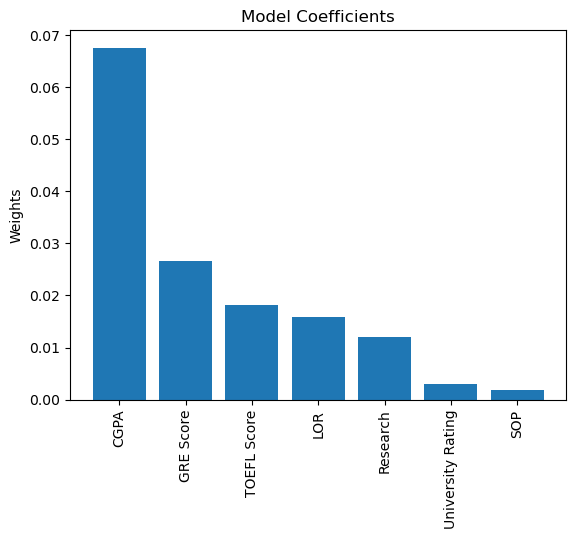

In [137]:
model_weights=list(zip(X_train.columns, model.coef_))
model_weights.sort(key=lambda x:x[1], reverse=True)

features = [i[0] for i in model_weights]
weights = [i[1] for i in model_weights]

plt.bar(x=features, height=weights)
plt.title('Model Coefficients')
plt.ylabel('Weights')
plt.xticks(rotation=90)
plt.show();

- CGPA & GRE scores have the highest weight
- SOP and University rating have the lowest weights

## Testing Assumptions of Linear Regression Model

### Multicolinearity Check
VIF (Variance Inflation Factor) is a measure that quantifies the severity of multicollinearity in a regression analysis. It assesses how much the variance of the estimated regression coefficient is inflated due to collinearity.

The formula for VIF is as follows:

VIF(j) = 1 / (1 - R(j)^2)

Where:

j represents the jth predictor variable. R(j)^2 is the coefficient of determination (R-squared) obtained from regressing the jth predictor variable on all the other predictor variables.

In [138]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
VIF = pd.DataFrame()
X_t = pd.DataFrame(X_train , columns=X_train.columns)
VIF['Features'] = X_train.columns
VIF['VIF'] = [variance_inflation_factor(X_t,i) for i in range(X_t.shape[1])]
VIF['VIF'] = round(VIF['VIF'],2)
VIF = VIF.sort_values(by='VIF', ascending=False)
VIF

,Features,VIF
5,CGPA,4.65
0,GRE Score,4.49
1,TOEFL Score,3.66
3,SOP,2.79
2,University Rating,2.57
4,LOR,1.98
6,Research,1.52


VIF Value of all Features are well below 5 which means low level of multicolinearity and we are good to go ahead

### Mean of Residuals  
The mean of residuals represents the average of residual values in a regression model. Residuals are the discrepancies or errors between the observed values and the values predicted by the regression model.

The mean of residuals is useful to assess the overall bias in the regression model. If the mean of residuals is close to zero, it indicates that the model is unbiased on average. However, if the mean of residuals is significantly different from zero, it suggests that the model is systematically overestimating or underestimating the observed values.

In [144]:
residuals= y_test.values - y_pred_test
print('Mean of Residuals: ', residuals.mean())

Mean of Residuals:  -0.012175000000000033


Since the mean of residuals is close to zero we can say that model is not biased

### Linearity of Variables
Linearity of variables refers to the assumption that there is a linear relationship between the independent variables and the dependent variable in a regression model. It means that the effect of the independent variables on the dependent variable is constant across different levels of the independent variables.

When we talk about "no pattern in the residual plot" in the context of linearity, we are referring to the plot of the residuals (the differences between the observed and predicted values of the dependent variable) against the predicted values or the independent variables.

Ideally, in a linear regression model, the residuals should be randomly scattered around zero, without any clear patterns or trends. This indicates that the model captures the linear relationships well and the assumption of linearity is met.

If there is a visible pattern in the residual plot, it suggests a violation of the linearity assumption. Common patterns that indicate non-linearity include:

1. Curved or nonlinear shape: The residuals form a curved or nonlinear pattern instead of a straight line.
2. U-shaped or inverted U-shaped pattern: The residuals show a U-shape or inverted U-shape, indicating a nonlinear relationship.
3. Funnel-shaped pattern: The spread of residuals widens or narrows as the predicted values or independent variables change, suggesting heteroscedasticity.
4. Clustering or uneven spread: The residuals show clustering or uneven spread across different levels of the predicted values or independent variables.

If a pattern is observed in the residual plot, it may indicate that the linear regression model is not appropriate, and nonlinear regression or other modeling techniques should be considered. Additionally, transformations of variables, adding interaction terms, or using polynomial terms can sometimes help capture nonlinear relationships and improve linearity in the residual plot.

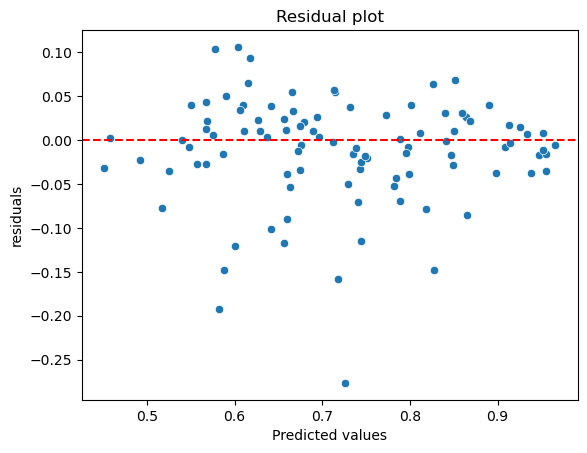

In [148]:
sns.scatterplot(x= y_pred_test , y = residuals)
plt.title("Residual plot")
plt.xlabel("Predicted values")
plt.ylabel("residuals")
plt.axhline(y=0 , color = 'r' , linestyle="--")
plt.show()

Since the residual plot shows no clear pattern or trend in residuals, we can conclude that linearity of variables exists

### Homoscedasticity
Homoscedasticity refers to the assumption in regression analysis that the variance of the residuals (or errors) should be constant across all levels of the independent variables. In simpler terms, it means that the spread of the residuals should be similar across different values of the predictors.

When homoscedasticity is violated, it indicates that the variability of the errors is not consistent across the range of the predictors, which can lead to unreliable and biased regression estimates.

To test for homoscedasticity, there are several graphical and statistical methods that you can use:

1. Residual plot: Plot the residuals against the predicted values or the independent variables. Look for any systematic patterns or trends in the spread of the residuals. If the spread appears to be consistent across all levels of the predictors, then homoscedasticity is likely met.

2. Scatterplot: If you have multiple independent variables, you can create scatter plots of the residuals against each independent variable separately. Again, look for any patterns or trends in the spread of the residuals.

3. Breusch-Pagan Test: This is a statistical test for homoscedasticity. It involves regressing the squared residuals on the independent variables and checking the significance of the resulting model. If the p-value is greater than a chosen significance level (e.g., 0.05), it suggests homoscedasticity. However, this test assumes that the errors follow a normal distribution.

4. Goldfeld-Quandt Test: This test is used when you suspect heteroscedasticity due to different variances in different parts of the data. It involves splitting the data into two subsets based on a specific criterion and then comparing the variances of the residuals in each subset. If the difference in variances is not significant, it suggests homoscedasticity.

It's important to note that the visual inspection of plots is often the first step to identify potential violations of homoscedasticity. Statistical tests can provide additional evidence, but they may have assumptions or limitations that need to be considered.

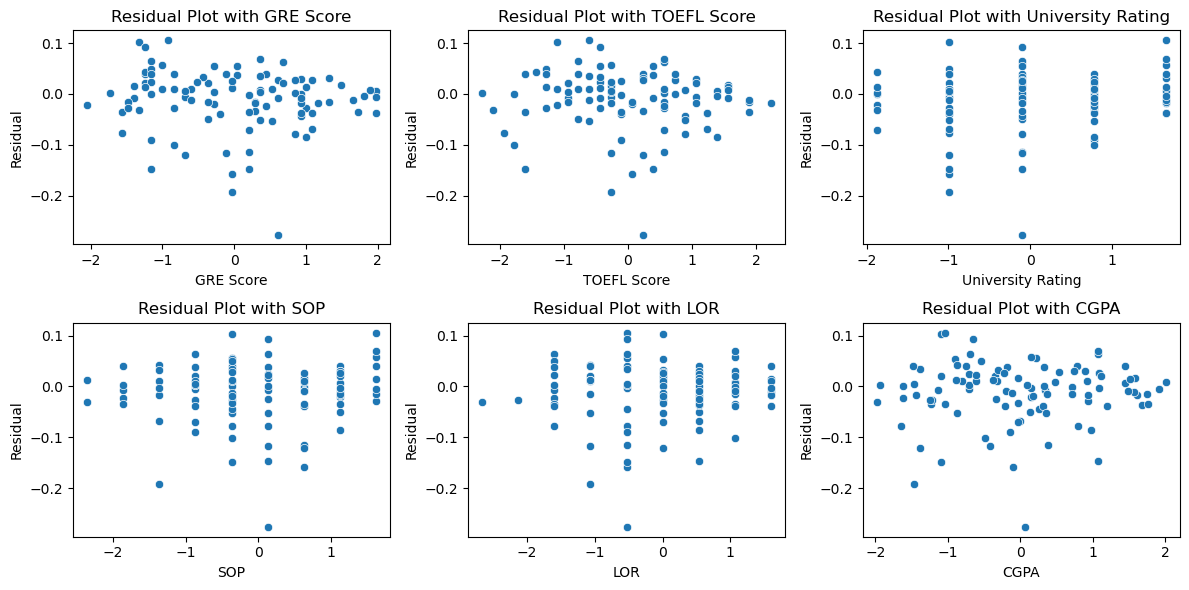

In [149]:
# Scatterplot of residuals with each independent variable to check for Homoscedasticity
plt.figure(figsize=(12,6))
i=1
for col in X_test.columns[:-1]:
  ax = plt.subplot(2,3,i)
  sns.scatterplot(x=X_test[col].values.reshape((-1,)), y=residuals.reshape((-1,)))
  plt.title(f'Residual Plot with {col}')
  plt.xlabel(col)
  plt.ylabel('Residual')
  i+=1

plt.tight_layout()
plt.show();

Using **Goldfeld Quandt Test** to check homoskedacity

In [153]:
from statsmodels.compat import lzip
import statsmodels.stats.api as sms

name = ['F statistic', 'p-value']
test = sms.het_goldfeldquandt(y_train, X_train)
lzip(name, test)

[('F statistic', 1.002931835836539), ('p-value', 0.4918984144278115)]

Since we do not see any significant change in the spread of residuals with respect to change in independent variables, we can conclude that homoscedasticity is 

From the goldfeld-quandt test:  
F Statistic comes out to be around 1 => Implying minimal difference in variance between groups.  
p-value of 0.492 indicates that this difference is statistically significant at conventional levels of significance (e.g., 0.05).  
Therefore, we accept the null hypothesis of homoscedasticity, and conclude that there is no strong evidence of heteroscedasticity in the data.

### Normality of Residuals
Normality of residuals refers to the assumption that the residuals (or errors) in a statistical model are normally distributed. Residuals are the differences between the observed values and the predicted values from the model.

The assumption of normality is important in many statistical analyses because it allows for the application of certain statistical tests and the validity of confidence intervals and hypothesis tests. When residuals are normally distributed, it implies that the errors are random, unbiased, and have consistent variability.

To check for the normality of residuals, you can follow these steps:

1. Residual Histogram: Create a histogram of the residuals and visually inspect whether the shape of the histogram resembles a bell-shaped curve. If the majority of the residuals are clustered around the mean with a symmetric distribution, it suggests normality.

2. Q-Q Plot (Quantile-Quantile Plot): This plot compares the quantiles of the residuals against the quantiles of a theoretical normal distribution. If the points in the Q-Q plot are reasonably close to the diagonal line, it indicates that the residuals are normally distributed. Deviations from the line may suggest departures from normality.

3. Shapiro-Wilk Test: This is a statistical test that checks the null hypothesis that the residuals are normally distributed. The Shapiro-Wilk test calculates a test statistic and provides a p-value. If the p-value is greater than the chosen significance level (e.g., 0.05), it suggests that the residuals follow a normal distribution. However, this test may not be reliable for large sample sizes.

4. Skewness and Kurtosis: Calculate the skewness and kurtosis of the residuals. Skewness measures the asymmetry of the distribution, and a value close to zero suggests normality. Kurtosis measures the heaviness of the tails of the distribution compared to a normal distribution, and a value close to zero suggests similar tail behavior.

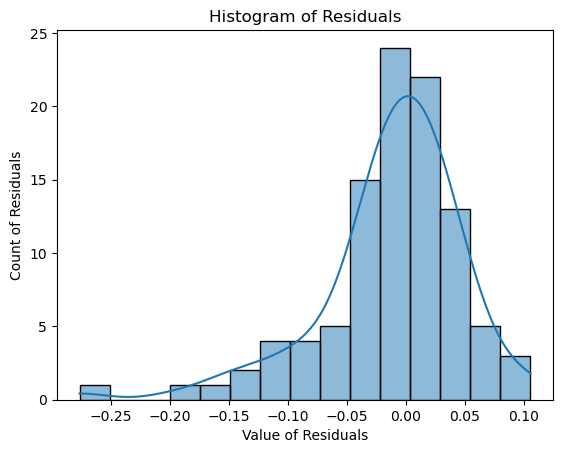

In [150]:
#Histogram of Residuals
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Value of Residuals')
plt.ylabel('Count of Residuals')
plt.show();

The histogram shows that there is a slight negative skew in the distribution of residuals but it is close to a normal distribution

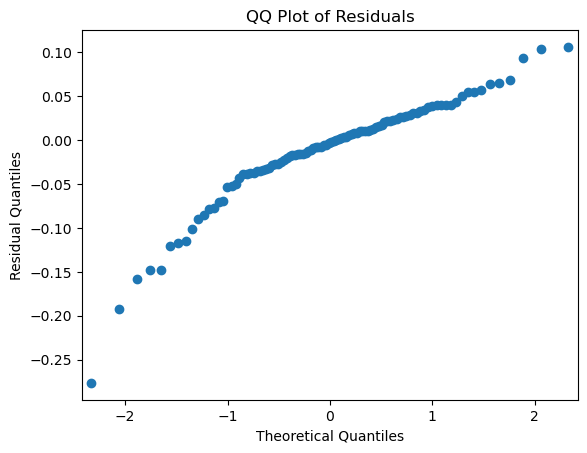

In [151]:
# QQ-Plot of residuals
sm.qqplot(residuals)
plt.title('QQ Plot of Residuals')
plt.ylabel('Residual Quantiles')
plt.show();

We can see that the variance of the residuals is constant at most of the levels of the independent variables, potentially indicating a supporting the Normality assumption in linear regression.

## Insights & Recommendations

### Insights:
- The distribution of target variable which is Chance of admit show strong correlation to CGPA, GRE score and TOEFL score
- Research shows weak correlation to all other factors.
- Most of the students belong to University with rating 3.
- Maximum students have got Statement of Purpose with strength 4
- Letter of Recommendation with strength 3 have got maximum number of students Most of the students have got research done
- Chance of Admit is highest for University with rating 5 followed by 4,3,2,1
- LOR with strength 5 has the maximum chance of admit
- Students who have done research have higher chance of admit
- Low Prob(F-statistic) value indicate that the model is statistically significant
- CGPA carry maximum weightage followed by GRE Score, TOEFL Score, LOR and Research signifying strength of relationship with the dependent variable
- The model predictor variables have met the conditons of assumptions - Multicolinearity, mean of residuals, linearity of variables, normality of residuals and homoscedasticity
- Linear Regression model performs well on both the training and testing sets, as indicated by small MAE and RMSE values and high R-squared and adjusted R-squared values.

### Recommendations:

- Encourage students to prioritize improving their GRE, TOEFL scores and LOR as these have the strongest correlation with admission chances
- Given its positive correlation with admission chances, students should be informed about the importance of having a research background
- Since all the exam scores are highly correlated, it is recommended to add more independent features for better prediction.
- Examples of other independent variables could be work experience, internships, mock interview performance, extracurricular activities or diversity variables
- Regularly evaluate the model's performance against new data and emerging trends in graduate admissions.